In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("../data/raw/demand.csv")

# Parse date
df["Date"] = pd.to_datetime(df["Date"])

# Clean Order_Demand
df["Order_Demand"] = (
    df["Order_Demand"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["Order_Demand"] = pd.to_numeric(df["Order_Demand"], errors="coerce")

df = (
    df.groupby(
        ["Product_Code", "Warehouse", "Product_Category", "Date"],
        as_index=False
    )["Order_Demand"]
    .sum()
)

df.duplicated(
    subset=["Product_Code", "Warehouse", "Date"]
).sum()

# Sort properly (CRITICAL)
df = df.sort_values(["Product_Code", "Warehouse", "Date"])

In [2]:
## Data Ordering for Time-Series Features

# The dataset is sorted by `Product_Code` and `Date` before creating lag features.

# This ensures that temporal operations like `shift()` correctly reference past demand values for the same product.
# Without proper sorting, lag features would be incorrect.

In [3]:
## Creating Lag Features

# Lag features allow the model to learn temporal dependencies.

# For each product, we create:

# - `lag_1`: Demand from previous day
# - `lag_7`: Demand from previous week
# - `lag_14`: Demand from two weeks ago

# These features help the model understand short-term and weekly demand behavior.

In [4]:
#creating lag features

df["lag_1"] = df.groupby(
    ["Product_Code", "Warehouse"]
)["Order_Demand"].shift(1)

df["lag_7"] = df.groupby(
    ["Product_Code", "Warehouse"]
)["Order_Demand"].shift(7)

df["lag_14"] = df.groupby(
    ["Product_Code", "Warehouse"]
)["Order_Demand"].shift(14)

In [5]:
df = df.dropna(subset = ["lag_1","lag_7","lag_14"])

In [6]:
## Why Grouping by Product_Code is Required

# Lag features are computed separately for each `Product_Code`.

# If grouping is not applied, demand values from different products would mix during the shift operation, causing data leakage.

# Grouping preserves product-level temporal behavior and ensures valid historical relationships.

In [7]:
## Rolling Window Features

# Rolling statistics summarize recent demand behavior.

# - `rolling_mean_7` captures short-term demand trend.
# - `rolling_std_7` captures short-term volatility.

# We shift before applying the rolling window to prevent using current-day information in feature computation, which would cause data leakage.

In [8]:
df["rolling_mean_7"] = (
    df.groupby(["Product_Code", "Warehouse"])["Order_Demand"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

df["rolling_std_7"] = (
    df.groupby(["Product_Code", "Warehouse"])["Order_Demand"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

In [9]:
df = df.dropna(subset=[
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7"
])

In [10]:
df[["Product_Code", "Warehouse", "Date", "Order_Demand", "lag_1"]].head(10) 

,Product_Code,Warehouse,Date,Order_Demand,lag_1
21,Product_0001,Whse_A,2012-07-02,5000.0,2000.0
22,Product_0001,Whse_A,2012-07-04,1000.0,5000.0
23,Product_0001,Whse_A,2012-07-23,2000.0,1000.0
24,Product_0001,Whse_A,2012-08-03,200.0,2000.0
25,Product_0001,Whse_A,2012-08-07,1000.0,200.0
26,Product_0001,Whse_A,2012-08-09,3000.0,1000.0
27,Product_0001,Whse_A,2012-08-13,200.0,3000.0
28,Product_0001,Whse_A,2012-08-15,400.0,200.0
29,Product_0001,Whse_A,2012-08-21,600.0,400.0
30,Product_0001,Whse_A,2012-08-23,1000.0,600.0


In [11]:
#calender features

df["day_of_week"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [12]:
## Calendar Features

# Calendar features help the model capture seasonal patterns such as weekly and monthly demand variations.

In [13]:
#one-hot encoding

df_encoded = pd.get_dummies(
    df,
    columns = ["Warehouse","Product_Category"],
    drop_first = True
)

In [14]:
features = df_encoded.drop(
    columns = ["Date","Order_Demand","Product_Code"]
)

target = df_encoded["Order_Demand"]

In [15]:
features.isna().sum().sum()

np.int64(0)

In [16]:
## Feature Encoding

# Warehouse and Product_Category are one-hot encoded.
# Product_Code is excluded to avoid extremely high dimensionality.

# The feature matrix now includes:
# - Lag features
# - Rolling features
# - Calendar features
# - Encoded categorical variables

In [17]:
df_encoded = df_encoded.sort_values("Date")

In [18]:
split_index = int(len(df_encoded)*0.8)

X_train = features.iloc[:split_index]
X_test = features.iloc[split_index:]

Y_train = target.iloc[:split_index]
Y_test = target.iloc[split_index:]

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
## Time-Aware Train-Test Split

# The dataset is split chronologically (80% train, 20% test).
# Random shuffling is avoided to preserve temporal structure.

In [21]:
#linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

lr = LinearRegression()

lr.fit(X_train_scaled,Y_train)

LinearRegression()

In [22]:
y_pred_lr = lr.predict(X_test_scaled)

In [23]:
mae_lr = mean_absolute_error(Y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(Y_test,y_pred_lr))

mae_lr,rmse_lr

(2597.29972370515, np.float64(9495.419786321117))

In [24]:
## Linear Regression Performance

# Linear Regression serves as the first ML baseline to evaluate whether engineered features improve forecasting performance.

In [25]:
#random forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42,
    n_jobs = -1
)

rf.fit(X_train,Y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [26]:
y_pred_rf = rf.predict(X_test)

In [27]:
mae_rf = mean_absolute_error(Y_test,y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(Y_test,y_pred_rf))

mae_rf, rmse_rf

(2546.385346513028, np.float64(12517.17159995085))

In [28]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index = X_train.columns
).sort_values(ascending = False)

feature_importance.head(10)

rolling_mean_7      0.466611
rolling_std_7       0.141544
lag_7               0.089297
lag_14              0.087259
lag_1               0.080583
month               0.041010
day_of_week         0.038608
quarter             0.014028
Warehouse_Whse_J    0.012252
Warehouse_Whse_S    0.011501
dtype: float64

In [29]:
## Random Forest Performance

# Random Forest captures nonlinear relationships and complex interactions between temporal and categorical features.

In [30]:
## Log Transformation Strategy

# The distribution of `Order_Demand` is highly right-skewed, with a small number of extremely large demand values.

# Such skewness negatively affects regression models because:
# - Large outliers dominate error metrics (especially RMSE).
# - Models struggle to balance low and high demand cases.

# To stabilize variance and reduce the impact of extreme values, we apply a log transformation:

# \[
# y_{log} = \log(1 + y)
# \]

# The `log1p` function is used to safely handle zero-demand cases.

# Models are trained on the transformed scale, and predictions are converted back to the original scale using `expm1` for evaluation.

In [31]:
import numpy as np

target_log = np.log1p(target)

In [32]:
y_train_log = target_log.iloc[:split_index]
y_test_log = target_log.iloc[split_index:]

In [33]:
#linear regression log
lr_log = LinearRegression()
lr_log.fit(X_train_scaled, y_train_log)

y_pred_lr_log = lr_log.predict(X_test_scaled)

In [34]:
y_pred_lr_actual = np.expm1(y_pred_lr_log)

In [35]:
mae_lr_log = mean_absolute_error(Y_test, y_pred_lr_actual)
rmse_lr_log = np.sqrt(mean_squared_error(Y_test, y_pred_lr_actual))

mae_lr_log, rmse_lr_log

(1704.1829505076485, np.float64(10072.006456076637))

In [36]:
# random forest log

rf_log = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_log.fit(X_train, y_train_log)

y_pred_rf_log = rf_log.predict(X_test)

y_pred_rf_actual = np.expm1(y_pred_rf_log)

In [37]:
mae_rf_log = mean_absolute_error(Y_test, y_pred_rf_actual)
rmse_rf_log = np.sqrt(mean_squared_error(Y_test, y_pred_rf_actual))

mae_rf_log, rmse_rf_log

(1524.678698328665, np.float64(9635.314641653173))

In [38]:
## Log Transformation of Target

# Due to extreme right-skewness in Order_Demand, a log(1 + y) transformation is applied.

# Models are trained on the transformed scale and predictions are converted back to the original scale for evaluation.

In [40]:
## Final Model Comparison

# Applying log transformation significantly improved performance due to the highly skewed nature of demand.

# Random Forest trained on log-transformed target achieved the best results.

# This demonstrates the importance of:
# - Understanding target distribution
# - Handling skewness properly
# - Iterative model refinement

In [44]:
drift_df = pd.DataFrame({
    "Date": df_encoded["Date"].iloc[split_index:].values,
    "Actual": Y_test.values,
    "Predicted": y_pred_rf_actual
})

drift_df["Absolute_error"] = abs(drift_df["Actual"]-drift_df["Predicted"])

In [45]:
drift_df["Month"] = pd.to_datetime(drift_df["Date"]).dt.to_period("M")

monthly_mae = (
    drift_df.groupby("Month")["Absolute_error"]
    .mean()
)

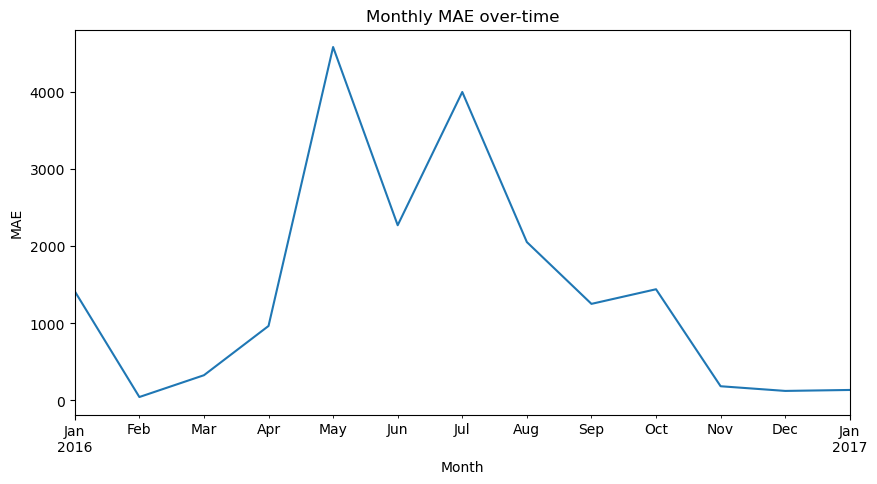

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,5))
monthly_mae.plot()
plt.title("Monthly MAE over-time")
plt.ylabel("MAE")
plt.show()